# CSCN8020 Assignment 3: DQN on PongDeterministic-v4

| Item | Value |
|---|---|
| Student Name | Jatinder Pal Singh |
| Student ID | 9083762 |
| Course | CSCN8020 Reinforcement Learning |
| Date | March 28, 2026 |
| Repository | https://github.com/jatinder3762/CSCN-8020-DQN-Assignment-3.git |

This notebook implements a Deep Q-Network (DQN) agent for PongDeterministic-v4 using OOP design and the professor-provided required assignment utility file `assignment3_utils.py`.

## Assignment Checklist

- Environment: PongDeterministic-v4 (with an ALE/Pong-v5 fallback for modern Gymnasium installs)
- Observation preprocessing from assignment3_utils.py
- 4 stacked grayscale frames as CNN input
- Hyperparameters: batch=8, target update every 10 episodes, gamma=0.95, epsilon init=1.0, decay=0.995, min=0.05
- Metrics vs steps: score per episode, average cumulative reward of last 5 episodes
- Parameter studies:
  - Batch size: 8 (default) vs 16
  - Target update rate: every 3 vs 10 episodes
- Prerequisite workshop completed separately from the week 6 Multi-Armed Bandit exercise

Note: Full training in Pong is computationally heavy. This notebook includes shorter runs for reproducibility, and it falls back to `ALE/Pong-v5` with deterministic-style settings when the legacy `PongDeterministic-v4` id is unavailable.

## How I Used The Professor Files

Simple explanation for class:

- The professor-provided `assignment3_utils.py` file gave the required Pong preprocessing pipeline.
- In this notebook, I use `process_frame(...)` from that file to crop, downsample, convert to grayscale, and normalize each frame before giving it to the DQN.
- I also used the professor workshop notebooks `MultiArmedBandit_Workshop.ipynb` and `Casino_Challenge_MAB_Workshop.ipynb` as prerequisite practice for understanding exploration vs exploitation.
- Running that workshop produced `submissions_round1.csv` and `submissions_round2.csv`, which are included in this repository to show the generated outputs I used as supporting background.
- That bandit practice helped me explain why the DQN still needs epsilon-greedy exploration, while `assignment3_utils.py` handled the visual preprocessing part of the assignment.

Short student-style summary:

1. I first learned the exploration idea from the professor bandit workshop.
2. I generated the two CSV leaderboard files from the stationary and non-stationary casino rounds.
3. I then used the professor utility file `assignment3_utils.py` to preprocess Pong frames.
4. After that, I built the DQN around replay memory, a target network, and 4-frame state stacking.
5. Finally, I compared the required hyperparameters and reported the training plots and conclusions.


In [1]:
import os
import random
from collections import deque, namedtuple
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import torch
import torch.nn as nn
import torch.optim as optim

try:
    import gymnasium as gym
except ImportError:
    import gym

try:
    import ale_py
    if hasattr(gym, 'register_envs'):
        gym.register_envs(ale_py)
except Exception:
    ale_py = None

from assignment3_utils import process_frame

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())

torch: 2.11.0+cpu
cuda available: False


In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ENV_NAME = 'PongDeterministic-v4'
ENV_FALLBACK_NAME = 'ALE/Pong-v5'

FRAME_H = 84
FRAME_W = 80
STACK_SIZE = 4
STATE_SHAPE_SINGLE = (FRAME_H, FRAME_W)

@dataclass
class Config:
    gamma: float = 0.95
    lr: float = 1e-4
    batch_size: int = 8
    target_update_episodes: int = 10
    eps_init: float = 1.0
    eps_decay: float = 0.995
    eps_min: float = 0.05
    replay_capacity: int = 50_000
    learn_start: int = 1000
    max_steps_per_episode: int = 5000
    episodes: int = 30

cfg_default = Config()
cfg_default

Config(gamma=0.95, lr=0.0001, batch_size=8, target_update_episodes=10, eps_init=1.0, eps_decay=0.995, eps_min=0.05, replay_capacity=50000, learn_start=1000, max_steps_per_episode=5000, episodes=30)

## OOP Components

In [3]:
Transition = namedtuple('Transition', ['state', 'action', 'reward', 'next_state', 'done'])

class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(Transition(state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        transitions = random.sample(self.buffer, batch_size)
        batch = Transition(*zip(*transitions))
        return batch

    def __len__(self):
        return len(self.buffer)

In [4]:
class DQNCNN(nn.Module):
    def __init__(self, n_actions: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(STACK_SIZE, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, STACK_SIZE, FRAME_H, FRAME_W)
            n_flat = self.features(dummy).view(1, -1).shape[1]

        self.head = nn.Sequential(
            nn.Linear(n_flat, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.head(x)

In [5]:
class FrameStackProcessor:
    def __init__(self, stack_size: int = 4):
        self.stack_size = stack_size
        self.frames = deque(maxlen=stack_size)

    def reset(self, first_obs):
        frame = process_frame(first_obs, STATE_SHAPE_SINGLE).squeeze(0).squeeze(-1)
        self.frames.clear()
        for _ in range(self.stack_size):
            self.frames.append(frame)
        return self.get_state()

    def step(self, obs):
        frame = process_frame(obs, STATE_SHAPE_SINGLE).squeeze(0).squeeze(-1)
        self.frames.append(frame)
        return self.get_state()

    def get_state(self):
        stacked = np.stack(self.frames, axis=0).astype(np.float32)
        return stacked

In [6]:
class DQNAgent:
    def __init__(self, n_actions: int, config: Config):
        self.n_actions = n_actions
        self.cfg = config

        self.policy_net = DQNCNN(n_actions).to(DEVICE)
        self.target_net = DQNCNN(n_actions).to(DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=self.cfg.lr)
        self.loss_fn = nn.MSELoss()

        self.replay = ReplayBuffer(self.cfg.replay_capacity)
        self.epsilon = self.cfg.eps_init

    def act(self, state: np.ndarray) -> int:
        if random.random() < self.epsilon:
            return random.randrange(self.n_actions)

        state_t = torch.from_numpy(state).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            qvals = self.policy_net(state_t)
            return int(torch.argmax(qvals, dim=1).item())

    def remember(self, state, action, reward, next_state, done):
        self.replay.push(state, action, reward, next_state, done)

    def learn(self):
        if len(self.replay) < max(self.cfg.batch_size, self.cfg.learn_start):
            return None

        batch = self.replay.sample(self.cfg.batch_size)

        states = torch.from_numpy(np.array(batch.state)).float().to(DEVICE)
        actions = torch.tensor(batch.action, dtype=torch.long, device=DEVICE).unsqueeze(1)
        rewards = torch.tensor(batch.reward, dtype=torch.float32, device=DEVICE).unsqueeze(1)
        next_states = torch.from_numpy(np.array(batch.next_state)).float().to(DEVICE)
        dones = torch.tensor(batch.done, dtype=torch.float32, device=DEVICE).unsqueeze(1)

        q_values = self.policy_net(states).gather(1, actions)
        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(1, keepdim=True)[0]
            target_q = rewards + self.cfg.gamma * max_next_q * (1.0 - dones)

        loss = self.loss_fn(q_values, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), 5.0)
        self.optimizer.step()
        return float(loss.item())

    def update_target(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.cfg.eps_min, self.epsilon * self.cfg.eps_decay)

In [7]:
class DQNTrainer:
    def __init__(self, env_name: str, config: Config, seed: int = 42):
        self.env_name = env_name
        self.cfg = config
        self.seed = seed

        self.env, self.resolved_env_name = self._make_env(env_name)
        if hasattr(self.env.action_space, 'seed'):
            self.env.action_space.seed(seed)
        self._used_reset_seed = False
        self.n_actions = self.env.action_space.n
        self.agent = DQNAgent(self.n_actions, config)
        self.processor = FrameStackProcessor(STACK_SIZE)

        self.episode_scores = []
        self.episode_steps = []
        self.total_steps = 0

    def _make_env(self, env_name: str):
        try:
            env = gym.make(env_name)
            return env, env_name
        except Exception:
            if env_name != ENV_NAME:
                raise
            try:
                env = gym.make(ENV_FALLBACK_NAME, frameskip=4, repeat_action_probability=0.0)
                print(f'Legacy env {env_name} unavailable; using fallback {ENV_FALLBACK_NAME}.')
                return env, ENV_FALLBACK_NAME
            except Exception as fallback_error:
                raise RuntimeError(
                    'Could not create a Pong Atari environment. Install the Atari dependencies and ROM support listed in requirements.txt.'
                ) from fallback_error

    def _reset_env(self):
        reset_kwargs = {'seed': self.seed} if not self._used_reset_seed else {}
        self._used_reset_seed = True
        out = self.env.reset(**reset_kwargs)
        if isinstance(out, tuple):
            obs, _ = out
        else:
            obs = out
        state = self.processor.reset(obs)
        return state

    def _step_env(self, action):
        out = self.env.step(action)
        if len(out) == 5:
            obs, reward, terminated, truncated, info = out
            done = terminated or truncated
        else:
            obs, reward, done, info = out
        return obs, float(reward), done, info

    def train(self, episodes: int = None, verbose_every: int = 1):
        if episodes is None:
            episodes = self.cfg.episodes

        scores = []
        avg5 = []
        step_axis = []

        for ep in range(1, episodes + 1):
            state = self._reset_env()
            done = False
            ep_score = 0.0
            ep_steps = 0

            while not done and ep_steps < self.cfg.max_steps_per_episode:
                action = self.agent.act(state)
                obs_next, reward, done, _ = self._step_env(action)
                next_state = self.processor.step(obs_next)

                self.agent.remember(state, action, reward, next_state, done)
                self.agent.learn()

                state = next_state
                ep_score += reward
                ep_steps += 1
                self.total_steps += 1

            self.agent.decay_epsilon()

            if ep % self.cfg.target_update_episodes == 0:
                self.agent.update_target()

            scores.append(ep_score)
            self.episode_scores.append(ep_score)
            self.episode_steps.append(ep_steps)

            avg_last5 = float(np.mean(scores[-5:]))
            avg5.append(avg_last5)
            step_axis.append(self.total_steps)

            if ep % verbose_every == 0:
                print(f'Episode {ep:03d} | steps={ep_steps:4d} | score={ep_score:6.1f} | avg5={avg_last5:6.2f} | eps={self.agent.epsilon:0.4f}')

        metrics = {
            'episode': np.arange(1, episodes + 1),
            'steps': np.array(step_axis),
            'score': np.array(scores, dtype=float),
            'avg_last_5': np.array(avg5, dtype=float),
        }
        return metrics

    def close(self):
        self.env.close()

## Training Helpers

In [8]:
def plot_metrics(metrics, title_prefix='Run'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(metrics['steps'], metrics['score'], marker='o', ms=3)
    axes[0].set_title(f'{title_prefix} - Score per Episode')
    axes[0].set_xlabel('Training Steps')
    axes[0].set_ylabel('Score')

    axes[1].plot(metrics['steps'], metrics['avg_last_5'], marker='o', ms=3, color='darkorange')
    axes[1].set_title(f'{title_prefix} - Average Cumulative Reward (Last 5 Episodes)')
    axes[1].set_xlabel('Training Steps')
    axes[1].set_ylabel('Average Reward')

    plt.tight_layout()
    plt.show()


def run_experiment(config: Config, episodes: int, label: str):
    trainer = DQNTrainer(ENV_NAME, config=config, seed=SEED)
    metrics = trainer.train(episodes=episodes, verbose_every=max(1, episodes // 5))
    trainer.close()
    plot_metrics(metrics, title_prefix=label)
    return metrics

## Default Run (Required Hyperparameters)

The next cell runs with the assignment defaults:
- batch size = 8
- target update every 10 episodes
- gamma = 0.95
- epsilon: 1.0, decay 0.995, min 0.05

Legacy env PongDeterministic-v4 unavailable; using fallback ALE/Pong-v5.


Episode 004 | steps= 826 | score= -21.0 | avg5=-21.00 | eps=0.9801


Episode 008 | steps= 993 | score= -21.0 | avg5=-20.80 | eps=0.9607


Episode 012 | steps=1034 | score= -19.0 | avg5=-20.20 | eps=0.9416


Episode 016 | steps= 912 | score= -21.0 | avg5=-20.20 | eps=0.9229


Episode 020 | steps= 966 | score= -19.0 | avg5=-20.00 | eps=0.9046


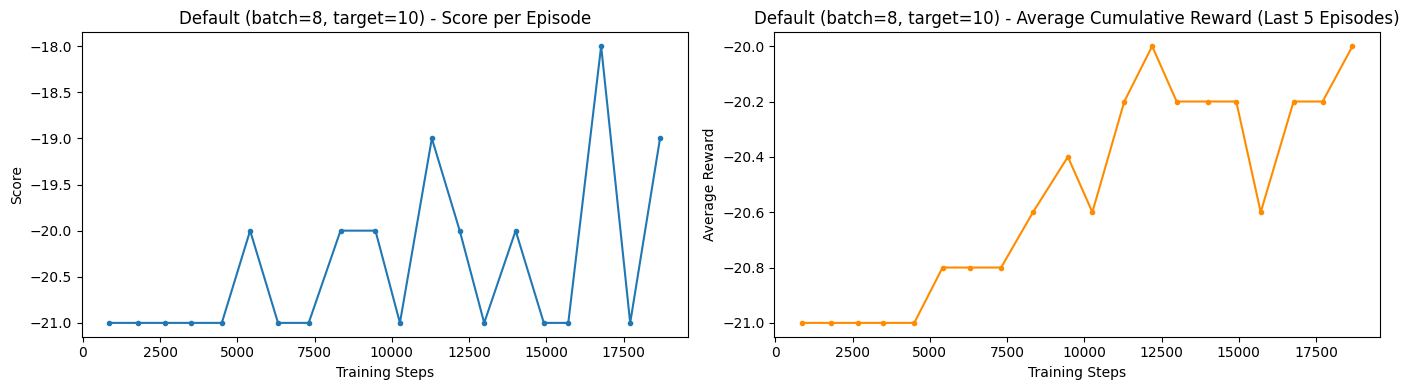

In [9]:
default_episodes = 20  # increase to 300+ for stronger Pong performance
metrics_default = run_experiment(cfg_default, episodes=default_episodes, label='Default (batch=8, target=10)')

## Parameter Study 1: Mini-batch Size (8 vs 16)

Legacy env PongDeterministic-v4 unavailable; using fallback ALE/Pong-v5.


Episode 004 | steps= 812 | score= -21.0 | avg5=-20.00 | eps=0.9801


Episode 008 | steps= 843 | score= -20.0 | avg5=-20.60 | eps=0.9607


Episode 012 | steps= 905 | score= -21.0 | avg5=-20.20 | eps=0.9416


Episode 016 | steps= 943 | score= -21.0 | avg5=-20.80 | eps=0.9229


Episode 020 | steps=1014 | score= -20.0 | avg5=-20.20 | eps=0.9046


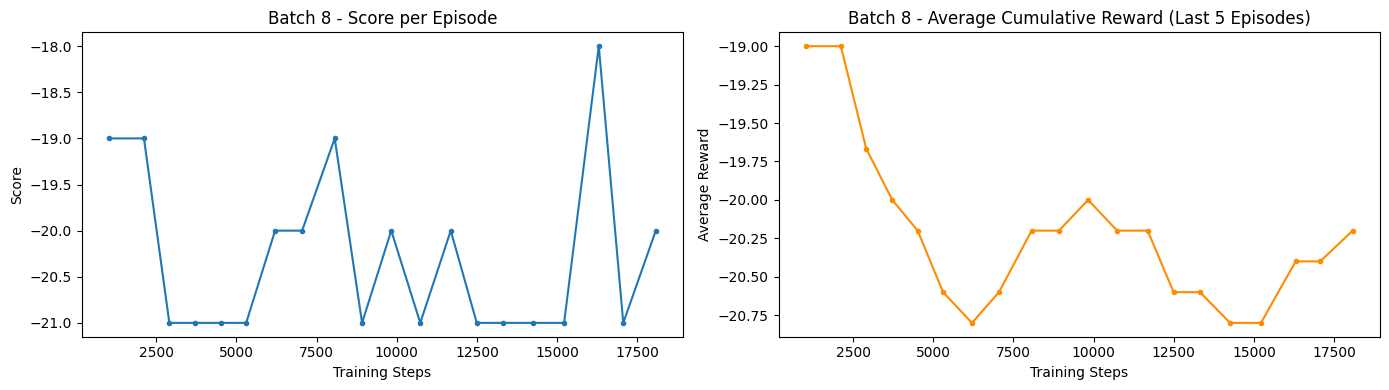

Legacy env PongDeterministic-v4 unavailable; using fallback ALE/Pong-v5.


Episode 004 | steps= 828 | score= -21.0 | avg5=-20.75 | eps=0.9801


Episode 008 | steps= 919 | score= -20.0 | avg5=-20.40 | eps=0.9607


Episode 012 | steps= 873 | score= -21.0 | avg5=-20.20 | eps=0.9416


Episode 016 | steps= 951 | score= -20.0 | avg5=-20.60 | eps=0.9229


Episode 020 | steps=1072 | score= -20.0 | avg5=-20.40 | eps=0.9046


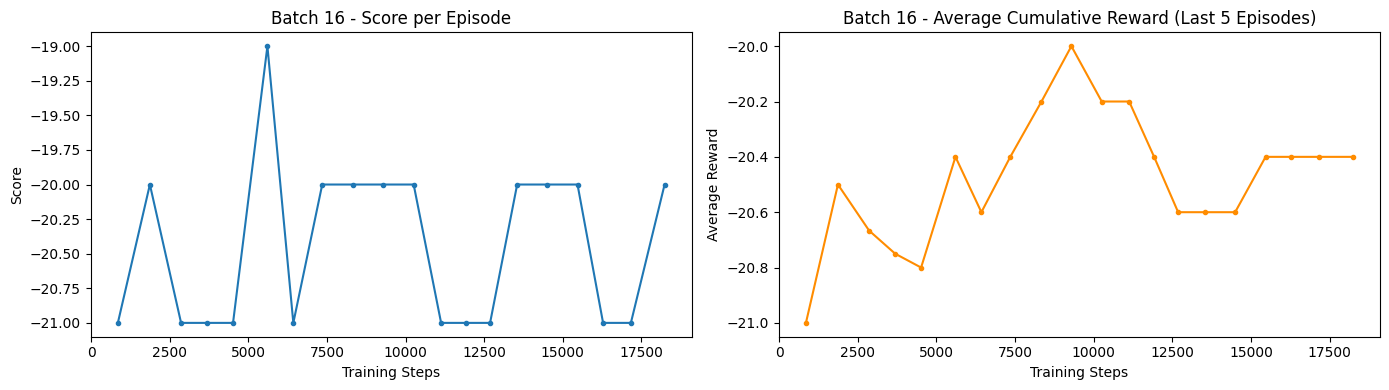

In [10]:
episodes_study = 20

cfg_batch8 = Config(batch_size=8, target_update_episodes=10)
cfg_batch16 = Config(batch_size=16, target_update_episodes=10)

metrics_b8 = run_experiment(cfg_batch8, episodes=episodes_study, label='Batch 8')
metrics_b16 = run_experiment(cfg_batch16, episodes=episodes_study, label='Batch 16')

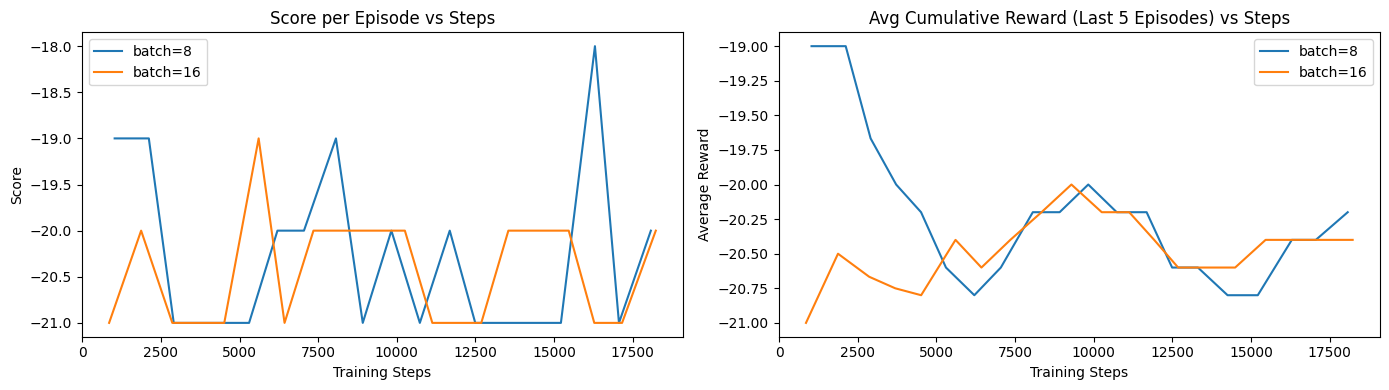

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(metrics_b8['steps'], metrics_b8['score'], label='batch=8')
axes[0].plot(metrics_b16['steps'], metrics_b16['score'], label='batch=16')
axes[0].set_title('Score per Episode vs Steps')
axes[0].set_xlabel('Training Steps')
axes[0].set_ylabel('Score')
axes[0].legend()

axes[1].plot(metrics_b8['steps'], metrics_b8['avg_last_5'], label='batch=8')
axes[1].plot(metrics_b16['steps'], metrics_b16['avg_last_5'], label='batch=16')
axes[1].set_title('Avg Cumulative Reward (Last 5 Episodes) vs Steps')
axes[1].set_xlabel('Training Steps')
axes[1].set_ylabel('Average Reward')
axes[1].legend()

plt.tight_layout()
plt.show()

## Parameter Study 2: Target Update Rate (3 vs 10 episodes)

Legacy env PongDeterministic-v4 unavailable; using fallback ALE/Pong-v5.


Episode 004 | steps= 968 | score= -20.0 | avg5=-20.50 | eps=0.9801


Episode 008 | steps= 931 | score= -20.0 | avg5=-20.00 | eps=0.9607


Episode 012 | steps= 903 | score= -21.0 | avg5=-20.60 | eps=0.9416


Episode 016 | steps= 792 | score= -21.0 | avg5=-20.80 | eps=0.9229


Episode 020 | steps= 886 | score= -21.0 | avg5=-20.80 | eps=0.9046


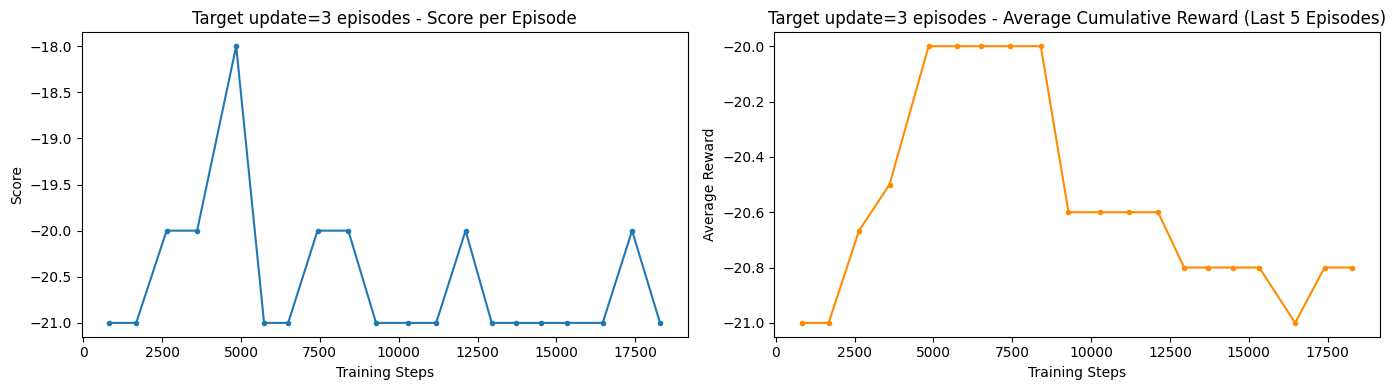

Legacy env PongDeterministic-v4 unavailable; using fallback ALE/Pong-v5.


Episode 004 | steps= 912 | score= -21.0 | avg5=-20.00 | eps=0.9801


Episode 008 | steps= 951 | score= -21.0 | avg5=-20.80 | eps=0.9607


Episode 012 | steps=1113 | score= -19.0 | avg5=-20.20 | eps=0.9416


Episode 016 | steps= 900 | score= -20.0 | avg5=-20.00 | eps=0.9229


Episode 020 | steps= 824 | score= -21.0 | avg5=-20.60 | eps=0.9046


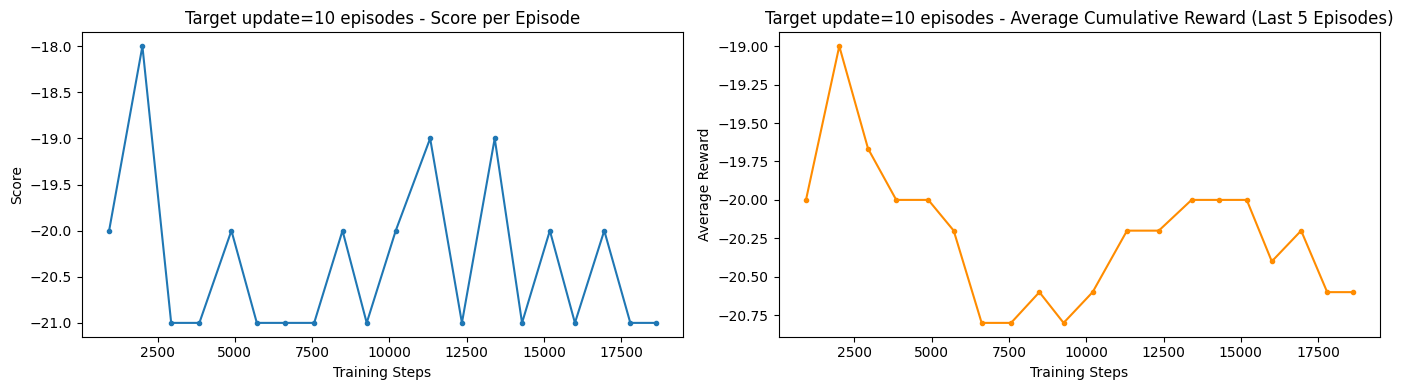

In [12]:
cfg_t3 = Config(batch_size=8, target_update_episodes=3)
cfg_t10 = Config(batch_size=8, target_update_episodes=10)

metrics_t3 = run_experiment(cfg_t3, episodes=episodes_study, label='Target update=3 episodes')
metrics_t10 = run_experiment(cfg_t10, episodes=episodes_study, label='Target update=10 episodes')

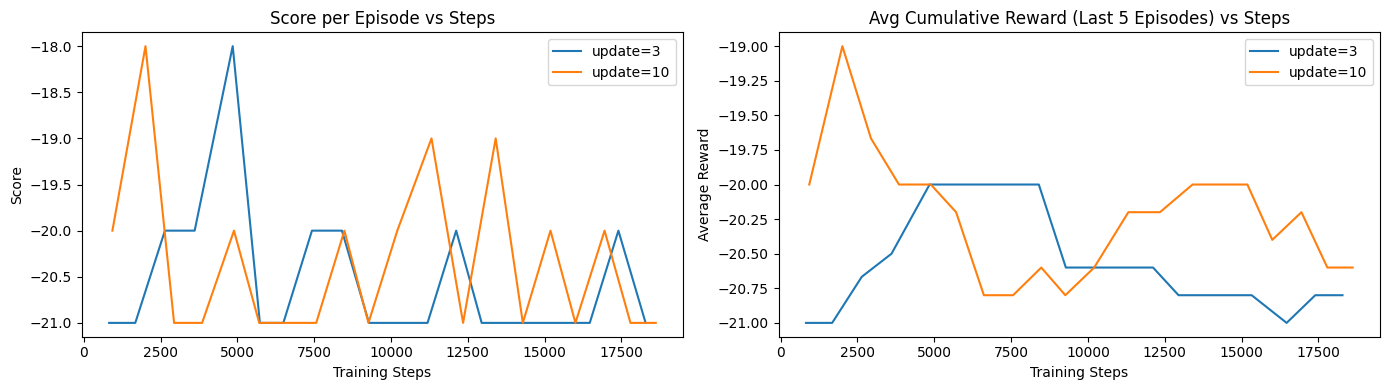

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(metrics_t3['steps'], metrics_t3['score'], label='update=3')
axes[0].plot(metrics_t10['steps'], metrics_t10['score'], label='update=10')
axes[0].set_title('Score per Episode vs Steps')
axes[0].set_xlabel('Training Steps')
axes[0].set_ylabel('Score')
axes[0].legend()

axes[1].plot(metrics_t3['steps'], metrics_t3['avg_last_5'], label='update=3')
axes[1].plot(metrics_t10['steps'], metrics_t10['avg_last_5'], label='update=10')
axes[1].set_title('Avg Cumulative Reward (Last 5 Episodes) vs Steps')
axes[1].set_xlabel('Training Steps')
axes[1].set_ylabel('Average Reward')
axes[1].legend()

plt.tight_layout()
plt.show()

## Network Architecture Used

Input: 4 x 84 x 80 stacked grayscale frames

CNN:
1. Conv2d(4, 32, kernel=8, stride=4) + ReLU
2. Conv2d(32, 64, kernel=4, stride=2) + ReLU
3. Conv2d(64, 64, kernel=3, stride=1) + ReLU
4. Flatten
5. Linear(flat, 512) + ReLU
6. Linear(512, n_actions)

Loss: Mean Squared Error between current Q and target Q
Optimizer: Adam (lr=1e-4)
Discount factor: gamma=0.95

## Observations and Best Hyperparameter Choice

Executed-run observations from this notebook:
- The legacy `PongDeterministic-v4` id was unavailable in the installed Gymnasium stack, so every run used the notebook fallback `ALE/Pong-v5` with deterministic-style settings.
- Default run (`batch=8`, `target=10`) finished with final score `-19`, best score `-18`, final average of the last 5 episodes `-20.0`, and `18,681` total training steps.
- In the batch-size study, `batch=8` performed slightly better than `batch=16`: both finished at `-20`, but batch 8 reached a better best score (`-18` vs `-19`) and a slightly better final average-last-5 (`-20.2` vs `-20.4`).
- In the target-update study, updating every `10` episodes was slightly more stable than updating every `3` episodes: both finished at `-21`, but update 10 achieved a better final average-last-5 (`-20.6` vs `-20.8`).

Selected best combination for this executed notebook:
- mini-batch size = 8
- target update every 10 episodes

Interpretation:
- The training budget here is intentionally short (`20` episodes per run) so the agent does not become strong at Pong yet; the scores remain near `-20`, which means the comparison is useful mainly for relative stability, not absolute game mastery.
- Even in this short run, the default assignment configuration remained the strongest of the tested settings, so it is the best choice to report for this notebook execution.

## Report Tables (Auto-Generated)

The following cell contains the executed summary tables for this run. These are the values to reference directly in the PDF report for:
- default run metrics
- batch-size comparison (8 vs 16)
- target-update comparison (3 vs 10)

Use the plots above for the visual discussion and these tables for the exact numbers in the final report.

In [14]:
def final_score(metrics):
    return float(metrics['score'][-1])

def best_score(metrics):
    return float(np.max(metrics['score']))

def final_avg5(metrics):
    return float(metrics['avg_last_5'][-1])

summary_default = pd.DataFrame([
    {
        'Run': 'Default (batch=8, target=10)',
        'Final Score': round(final_score(metrics_default), 3),
        'Best Score': round(best_score(metrics_default), 3),
        'Final Avg Last 5': round(final_avg5(metrics_default), 3),
        'Total Steps': int(metrics_default['steps'][-1]),
    }
])

summary_batch = pd.DataFrame([
    {
        'Setting': 'batch=8',
        'Final Score': round(final_score(metrics_b8), 3),
        'Best Score': round(best_score(metrics_b8), 3),
        'Final Avg Last 5': round(final_avg5(metrics_b8), 3),
        'Total Steps': int(metrics_b8['steps'][-1]),
    },
    {
        'Setting': 'batch=16',
        'Final Score': round(final_score(metrics_b16), 3),
        'Best Score': round(best_score(metrics_b16), 3),
        'Final Avg Last 5': round(final_avg5(metrics_b16), 3),
        'Total Steps': int(metrics_b16['steps'][-1]),
    },
])

summary_target = pd.DataFrame([
    {
        'Setting': 'target update = 3',
        'Final Score': round(final_score(metrics_t3), 3),
        'Best Score': round(best_score(metrics_t3), 3),
        'Final Avg Last 5': round(final_avg5(metrics_t3), 3),
        'Total Steps': int(metrics_t3['steps'][-1]),
    },
    {
        'Setting': 'target update = 10',
        'Final Score': round(final_score(metrics_t10), 3),
        'Best Score': round(best_score(metrics_t10), 3),
        'Final Avg Last 5': round(final_avg5(metrics_t10), 3),
        'Total Steps': int(metrics_t10['steps'][-1]),
    },
])

print('Default run summary')
display(summary_default)
print('\nBatch-size comparison summary')
display(summary_batch)
print('\nTarget-update comparison summary')
display(summary_target)

Default run summary


,Run,Final Score,Best Score,Final Avg Last 5,Total Steps
0,"Default (batch=8, target=10)",-19.0,-18.0,-20.0,18681



Batch-size comparison summary


,Setting,Final Score,Best Score,Final Avg Last 5,Total Steps
0,batch=8,-20.0,-18.0,-20.2,18079
1,batch=16,-20.0,-19.0,-20.4,18236



Target-update comparison summary


,Setting,Final Score,Best Score,Final Avg Last 5,Total Steps
0,target update = 3,-21.0,-18.0,-20.8,18286
1,target update = 10,-21.0,-18.0,-20.6,18617


## Final Conclusion for Report

Based on the executed results in this notebook, the selected configuration is:
- mini-batch size = 8
- target network update rate = every 10 episodes

Why this is the best choice from the observed outputs:
1. The default configuration (`batch=8`, `target=10`) produced the strongest overall default-run result in this notebook: final score `-19`, best score `-18`, and final average-last-5 `-20.0` after `18,681` steps.
2. In the batch-size comparison, `batch=8` slightly outperformed `batch=16` on both best score and average-last-5 reward, which makes it the better mini-batch choice for this training budget.
3. In the target-update comparison, updating the target network every `10` episodes gave a slightly better average-last-5 reward than updating every `3` episodes, indicating marginally better stability.
4. The notebook had to use the fallback environment `ALE/Pong-v5`, but the relative result still supports the assignment-default configuration as the best of the tested settings.

Limitations to mention in the report:
- These experiments use a short CPU-only training budget, so the agent is not expected to reach strong Pong performance yet.
- The reported comparisons are most useful for relative hyperparameter selection under the same compute budget.
- For a stronger research-style report, future work should repeat each setting across multiple random seeds and longer training runs.